<span style="font-size:40px; color:darkturquoise; font-weight: bold; text-shadow: 2px 2px 4px #cdd153"> 🐍***SPRINT 11: Visualització de Dades***--👨🏾‍💻👨🏾‍🎨🎨-----🏃🏾‍♂️‍➡️

<span style="color: turquoise; font-size:40px">**Nivell 1**</span>

<span style="font-size:14px">Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.</span>

1. <span style="font-size:14px">Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.</span>

    * <span style="font-size:14px">[Exemples de codi de conexió](https://dev.mysql.com/doc/connector-python/en/connector-python-examples.html)</span>
    
    * <span style="font-size:14px">[Com connectar Python i MySQL: pas a pas](https://pynative.com/python-mysql-database-connection/) </span>
2. <span style="font-size:14px">Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.</span>

<span style="font-size:14px">Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.</span>

* <span style="font-size:14px">Una variable numèrica.</span>
* <span style="font-size:14px">Dues variables numèriques.</span>
* <span style="font-size:14px">Una variable categòrica.</span>
* <span style="font-size:14px">Una variable categòrica i una numèrica.</span>
* <span style="font-size:14px">Dues variables categòriques.</span>
* <span style="font-size:14px">Tres variables combinades.</span>
* <span style="font-size:14px">Crea un Pairplot.</span>

In [3]:
# import mysql.connector  ---> L'import dins la funció per evitar problemes d'importació si no es té la llibreria instal·lada
import pandas as pd

<span style="font-size:14px; color:magenta">**Creem una funció que ens permiti conectar-nos de forma automàtica a la base de dades. La funció ha de fer el següent:**

1. <span style="font-size:14px">Es connecta a MySQL <br>
2. <span style="font-size:14px">Llegeix totes les taules de la base de dades
3. <span style="font-size:14px">Les carrega en un diccionari de DataFrames
4. <span style="font-size:14px">Et retorna aquest diccionari llest per treballar 


In [4]:
def load_mysql_tables(host, user, password, database):
    """
    Carrega totes les taules d'una base de dades MySQL com a DataFrames.
    Retorna:
        dict: {nom_taula: DataFrame}
    """
    import mysql.connector
    import pandas as pd
    # Connexió
    conn = mysql.connector.connect(
        host=host,
        user=user,
        password=password,
        database=database
    )

    cursor = conn.cursor()

    # Obtenir totes les taules
    cursor.execute("SHOW TABLES")
    taules = [t[0] for t in cursor.fetchall()]

    # Carregar cada taula com a DataFrame
    dfs = {}
    for t in taules:
        dfs[t] = pd.read_sql(f"SELECT * FROM {t}", conn)

    conn.close()
    return dfs

In [5]:
dfs = load_mysql_tables(
    host="localhost",
    user="root",
    password="aCMv2031dD62K5",
    database="Sprint_4"
)

C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\3556641710.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[t] = pd.read_sql(f"SELECT * FROM {t}", conn)


In [6]:
# Importem una taula de la base de dades per comprovar que la conexió la s'ha fet correctmant:
#Però abans mirem que conté la base de dades a la que ens hem connectat:
#dfs.keys() --->retorna una llista de les claus del diccionari.
for taula in dfs:
    print(taula)

american_users
card_status
company
credit_cards
european_users
products
raw_tp_ids
transaction_products
transactions
users


In [7]:
#Carreguem totes les taules. Després, ja veurem amb quines treballem i quines no. 
american_df=dfs["american_users"]
card_status_df=dfs["card_status"]
company_df=dfs["company"]
ccard_df=dfs["credit_cards"]
european_df=dfs["european_users"]
products_df=dfs["products"]
transac_product_df=dfs["transaction_products"]
transactions_df=dfs["transactions"]
users_df=dfs["users"]

<span style="font-size:14px; color:magenta">**Abans de treballar amb les dades de les taules i considerant les visualitzacións que s'ens demana fer, anem a condicionar les dades. ¿Què volem dir amb codicionar les dades? Preparem les dades seguint el mètode ETL (Extreure, Transformar i Carregar(load)). Donat que ja hem fet l'extracció, important-les des de mySQL ara toca el proces de transformar.**

 1. <span style="font-size:14px; color: darkgrey">**Seleccionem les taules amb les que volem treballar.** 
 2. <span style="font-size:14px; color:darkgrey">**Unim les taules amb les que volem treballar.** 
 3. <span style="font-size:14px; color:darkgrey">**Eliminem aquelles columnes que no utilitzarem** 
 4. <span style="font-size:14px; color:darkgrey">**Comencem el procés de visualització**

In [8]:
for i, dfs in enumerate([american_df,
                         card_status_df,
                         ccard_df,
                         european_df,
                         products_df,
                         transactions_df,
                         users_df,
                         transac_product_df,
                         company_df]):
    print(f'columnas df {i}: {list(dfs.columns)}')

columnas df 0: ['id', 'name', 'surname', 'phone', 'email', 'birth_date', 'country', 'city', 'postal_code', 'address']
columnas df 1: ['card_id', 'status']
columnas df 2: ['id', 'user_id', 'iban', 'pan', 'pin', 'cvv', 'tranck1', 'tranck2', 'expering_date']
columnas df 3: ['id', 'name', 'surname', 'phone', 'email', 'birth_date', 'country', 'city', 'postal_code', 'address']
columnas df 4: ['id', 'product_name', 'price', 'colour', 'weight', 'warehouse_id']
columnas df 5: ['id', 'card_id', 'company_id', 'timestamp', 'amount', 'declined', 'product_ids', 'user_id', 'lat', 'longitude']
columnas df 6: ['id', 'name', 'surname', 'phone', 'email', 'birth_date', 'country', 'city', 'postal_code', 'address']
columnas df 7: ['transaction_id', 'product_id']
columnas df 8: ['company_id', 'company_name', 'phone', 'email', 'country', 'website']


<span style="font-size:14px">*Construim el nostre ***super_df*** amb les taules a treballar. És a dir, anem a transformar les dades.*

In [9]:
transac_product_df.rename(columns={"transaction_id":"id"}, inplace=True)
transac_product_df.head()

,id,product_id
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1


In [10]:
super_df=pd.merge(transactions_df, transac_product_df, 
                  how='inner',
                  on='id')
super_df.head(3)

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,26
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,87


In [11]:
#Vull que cada product_id tingui la seva propia fila. Donat que fer el merge de les dos columnes a la vegade és un mal de cap. 
#Provarem de resoldra-ho d'aquesta forma:
import string
super_df = super_df.assign(product_ids=super_df['product_ids'].str.split(',')).explode('product_ids')
super_df['product_ids'] = super_df['product_ids'].astype(int)

In [12]:
super_df.head()

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,46.1999,1.43554,16
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,26,4713,46.1999,1.43554,16
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,97,4713,46.1999,1.43554,16
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,87,4713,46.1999,1.43554,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,46.1999,1.43554,26


In [13]:
#Canviem nom serie 'id' de df_products a 'product_ids'
products_df.rename(columns={'id':'product_ids'}, inplace=True)
products_df.head()

,product_ids,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,$161.11,#7c7c7c,1.0,WH-4
1,2,Tarly Stark,$9.24,#919191,2.0,WH-3
2,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2
3,4,warden south duel,$71.89,#111111,3.0,WH-1
4,5,skywalker ewok,$171.22,#dbdbdb,3.2,WH-0


In [14]:
#Unim el Super_df amb products_df per tenir la informació de cada producte:
super_df=pd.merge(super_df, products_df, 
                  how='inner', 
                  on='product_ids')
super_df.head(2)

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,product_id,product_name,price,colour,weight,warehouse_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,46.1999,1.43554,16,the duel warden,$180.91,#666666,3.0,WH--11
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,26,4713,46.1999,1.43554,16,Stark Karstark,$53.01,#898989,2.0,WH--21


In [15]:
#Abans de fer el merge amb el df_company, fem la neteja d'aquest super_df.
super_df=super_df.drop(columns=['lat','longitude','colour', 'weight', 'warehouse_id', 'product_id'])
super_df.head(2)

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,the duel warden,$180.91
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,26,4713,Stark Karstark,$53.01


In [16]:
#Afegim les dades de les companyies contingudes en el df_company
company_df.rename(columns={'id':'company_id'}, inplace=True)
company_df.head(2)

,company_id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r


In [17]:
super_df=pd.merge(super_df, company_df, 
                        on='company_id', 
                        how='inner')
super_df.head()

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price,company_name,phone,email,country,website
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,the duel warden,$180.91,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,26,4713,Stark Karstark,$53.01,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,97,4713,jinn Winterfell,$65.25,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,87,4713,sith Jade,$96.26,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
4,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,the duel warden,$180.91,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r


In [18]:
super_df=super_df.drop(columns=['phone', 'email'])
super_df.head()

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price,company_name,country,website
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,the duel warden,$180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,26,4713,Stark Karstark,$53.01,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,97,4713,jinn Winterfell,$65.25,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,87,4713,sith Jade,$96.26,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
4,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,16,4713,the duel warden,$180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r


In [19]:
super_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769155 entries, 0 to 769154
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            769155 non-null  object 
 1   card_id       769155 non-null  object 
 2   company_id    769155 non-null  object 
 3   timestamp     769155 non-null  object 
 4   amount        769155 non-null  float64
 5   declined      769155 non-null  int64  
 6   product_ids   769155 non-null  int64  
 7   user_id       769155 non-null  int64  
 8   product_name  769155 non-null  object 
 9   price         769155 non-null  object 
 10  company_name  769155 non-null  object 
 11  country       769155 non-null  object 
 12  website       769155 non-null  object 
dtypes: float64(1), int64(3), object(9)
memory usage: 76.3+ MB


<span style="font-size:14px; color:magenta">Ara que ja hem generat el nostre **super_df** amb les taules que volem treballar, toca seguir amb el procés de transformació. Hi ha columnes com ara *timestamp* que s'hauria de transformar del tipus <class **'object'**> a <class **'datetime64[ns]'**>. També hi ha columnes com ara *declined* que es poden transformar a tipus boolean. Aquest procés de transformació ens ajudarà a fer les visualitzacions més fàcils i més eficients.</span>

<span style="font-size:14px; color:magenta">Per altre banda, tenim la columna *price* que és el preu del producte, que s'hauria de transformar a tipus numèric. </span>


In [20]:
#Transformem la columna 'timestamp' a datetime
super_df['timestamp'] = pd.to_datetime(super_df['timestamp'])
super_df.timestamp.dtype

dtype('<M8[ns]')

In [21]:
#Transformem la columna 'declined' a boolean 
super_df['declined']=super_df['declined'].astype(bool)
super_df.declined.dtype

dtype('bool')

In [22]:
#Transformem la columna 'price' a nùmeric
super_df['price']=super_df['price'].str.replace('$', '').astype(float)
super_df.price.dtype

dtype('float64')

In [23]:
#L'índex passa a ser el "ID" de la transacció:
super_df=super_df.set_index("id")
super_df.head(2)

,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price,company_name,country,website
id,,,,,,,,,,,,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,16,4713,the duel warden,180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,26,4713,Stark Karstark,53.01,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r


In [24]:
super_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769155 entries, 00043A49-2949-494B-A5DD-A5BAE3BB19DD to FFFD31D6-9495-47CE-B54A-7DB8E1CC274B
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   card_id       769155 non-null  object        
 1   company_id    769155 non-null  object        
 2   timestamp     769155 non-null  datetime64[ns]
 3   amount        769155 non-null  float64       
 4   declined      769155 non-null  bool          
 5   product_ids   769155 non-null  int64         
 6   user_id       769155 non-null  int64         
 7   product_name  769155 non-null  object        
 8   price         769155 non-null  float64       
 9   company_name  769155 non-null  object        
 10  country       769155 non-null  object        
 11  website       769155 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 71.2+ MB


In [25]:
super_df

,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price,company_name,country,website
id,,,,,,,,,,,,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,16,4713,the duel warden,180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,26,4713,Stark Karstark,53.01,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,97,4713,jinn Winterfell,65.25,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,87,4713,sith Jade,96.26,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,16,4713,the duel warden,180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
...,...,...,...,...,...,...,...,...,...,...,...,...
FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,148.91,False,18,680,Karstark warden,148.91,Amet Nulla Donec Corporation,Italy,https://netflix.com/sub/cars\r
FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,CcS-5684,b-2450,2021-08-05 12:26:24,74.54,False,48,1103,rock Renly in,21.53,Turpis Company,Netherlands,https://instagram.com/sub\r
FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,CcS-5684,b-2450,2021-08-05 12:26:24,74.54,False,26,1103,Stark Karstark,53.01,Turpis Company,Netherlands,https://instagram.com/sub\r


<span style="font-size:17px; color:violet">**Ara ja tenim la informació de les transaccions, els productes i les companyies en un únic DataFrame. Ara podem començar a fer les visualitzacions que ens interessin.**

<span style="font-size:14px">Tenim els dos tipus de variables que necessitem: ***numèriques*** i ***categòriques***.

In [26]:
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

* <span style="font-size:20px">**Una variable numèrica.**

<span style="font-size:14px; color:deepskyblue">He escollit la variable "amount" per visualitzar la variable numèrica. Aquesta variable representa l'import de cada transacció, i és una variable clau per entendre el comportament de les vendes i les transaccions en el nostre dataset. Visualitzar aquesta variable ens permetrà identificar patrons, tendències i possibles anomalies en els imports de les transaccions.</span> 

<span style="font-size:14px; color:deepskyblue">La visualització que he escollit és un boxplot. El boxplot és una eina gràfica que ens permet veure la distribució de la variable numèrica, identificar possibles valors atípics (*outliers*) i comparar la mediana amb els quartils. És una manera efectiva de resumir la informació estadística de la variable "amount" i detectar qualsevol anomalia en les dades.</span>

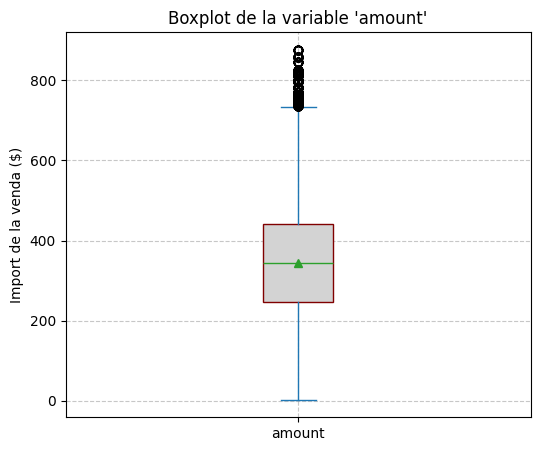

In [27]:
#Utilitzarem la variable "amount" per visualitzar la variable numèrica
plt.figure(figsize=(6, 5))
super_df["amount"].plot(kind="box",
                               showfliers=True,  # Mostrar valors atípics (outliers)
                               showmeans=True,  # Mostrar la mitjana com una línia dins del boxplot
                               ylabel="Import de la venda ($)",
                               patch_artist=True,  # Omplir el boxplot amb color
                               boxprops=dict({
                                   #'color':'grey', 
                                   'facecolor':'lightgrey', 
                                   'edgecolor':'maroon'}))

plt.title("Boxplot de la variable 'amount'")
plt.grid(True, linestyle='--', alpha=0.7)

#Per què aquesta visualització? El boxplot ens permet veure la distribució de la variable numèrica, identificar possibles valors atípics (outliers) i comparar la mediana amb els quartils. 
#És una manera efectiva de resumir la informació estadística de la variable "amount" i detectar qualsevol anomalia en les dades.

* <span style="font-size:20px">**Dues variables numèriques.**

<span style="font-size:14px; color:deepskyblue"> Com a variables numèriques podem treballar amb *amount* i *timestamp* (que és la data de la transacció). Amb aquestes dues variables podem estudiar les vendes realitzades al llarg dels anys. D'aquesta manera, podem veure si hi ha una tendència de creixement o decreixement en les vendes al llarg del temps. També podem veure si hi ha estacionalitat, és a dir, si hi ha períodes de l'any on les vendes són més altes o més baixes.

<span style="font-size:14px; color:deepskyblue">La visualització que he escollit per aquestes dues variables és un gràfic de línies. El gràfic de línies ens permet veure l'evolució de les vendes al llarg del temps, i identificar qualsevol patró o tendència en les dades. És una manera efectiva de visualitzar la relació entre el temps i les vendes.</span>

<span style="font-size:14px; color:red">**Una alternativa a la gràfica de línies és un gràfic de dispersió (scatter plot), que pot mostrar la relació entre les dues variables numèriques de manera més detallada.**</span>

<span style="font-size:16px; color:maroon">**Farem les dues visualitzacions**

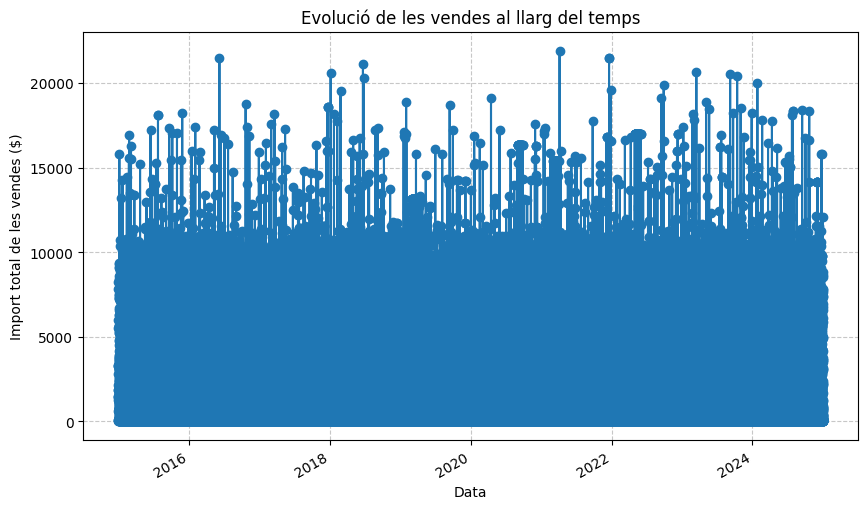

In [28]:
# Gràfic de línies per veure l'evolució de les vendes al llarg del temps
plt.figure(figsize=(10, 6))
super_df.groupby('timestamp')['amount'].sum().plot(kind='line', marker='o') #marker --> per marcar els punts de dades amb cercles
plt.title("Evolució de les vendes al llarg del temps")
plt.xlabel("Data")
plt.ylabel("Import total de les vendes ($)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<span style="font-size:14px; color: deepskyblue">Resulta bastant caòtica aquesta visualització i difícil d'interpretar, però ens permet veure l'evolució de les vendes al llarg del temps. Podem veure que hi ha una tendència de creixement en les vendes al llarg dels anys, amb alguns pics i caigudes que podrien estar relacionats amb estacionalitat o altres factors externs. També podem veure que hi ha alguns valors atípics (outliers) en els imports de les transaccions, que podrien ser deguts a errors en les dades o a transaccions excepcionals. En general, aquesta visualització ens ajuda a comprendre millor el comportament de les vendes al llarg del temps i a identificar possibles àrees d'interès per a un anàlisi més detallat.</span>

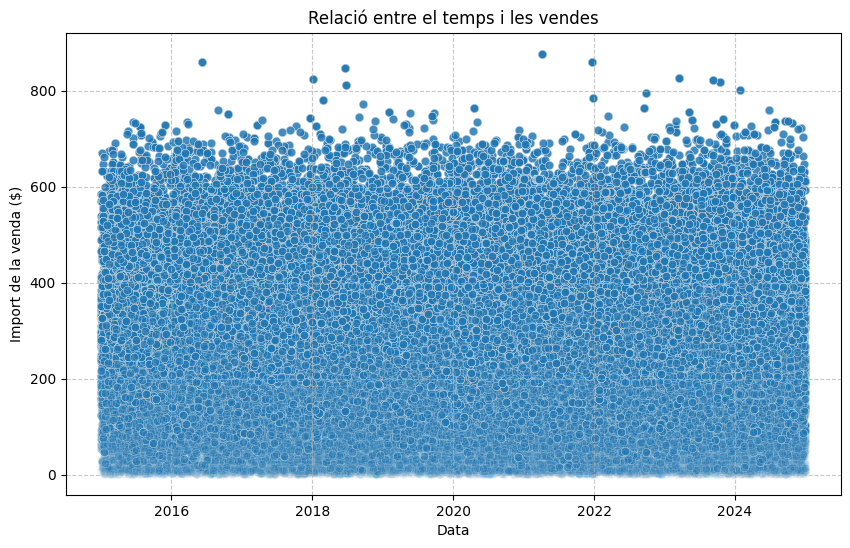

In [29]:
# A veure amb l'scatter plot:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=super_df,
                x='timestamp',
                y='amount',
                alpha=0.1)
plt.title("Relació entre el temps i les vendes")
plt.xlabel("Data")
plt.ylabel("Import de la venda ($)")
plt.grid(True, linestyle='--', alpha=0.7)


<span style="font-size:14px; color:red">**Queda molt saturada la visualització amb l'scatter plot. Hi ha masses punts i és difícil veure cap patró clarament.** Per tant, ajustarem la visualització i farem un gràfic de línies amb una mitjana mòbil per suavitzar les dades i veure millor la tendència general de les vendes al llarg del temps.</span>

<span style="font-size:14px; color:deepskyblue">La mitjana mòbil ens serveix per reduir el soroll de les dades i ressaltar les tèndencies generals. El que fa és calcular la mitjana d'un nombre determinat de valors consecutius per els últims 30 dies o el periode que li haguem especificat. En el nostre cas és cada 30 dies o cada mes</span>

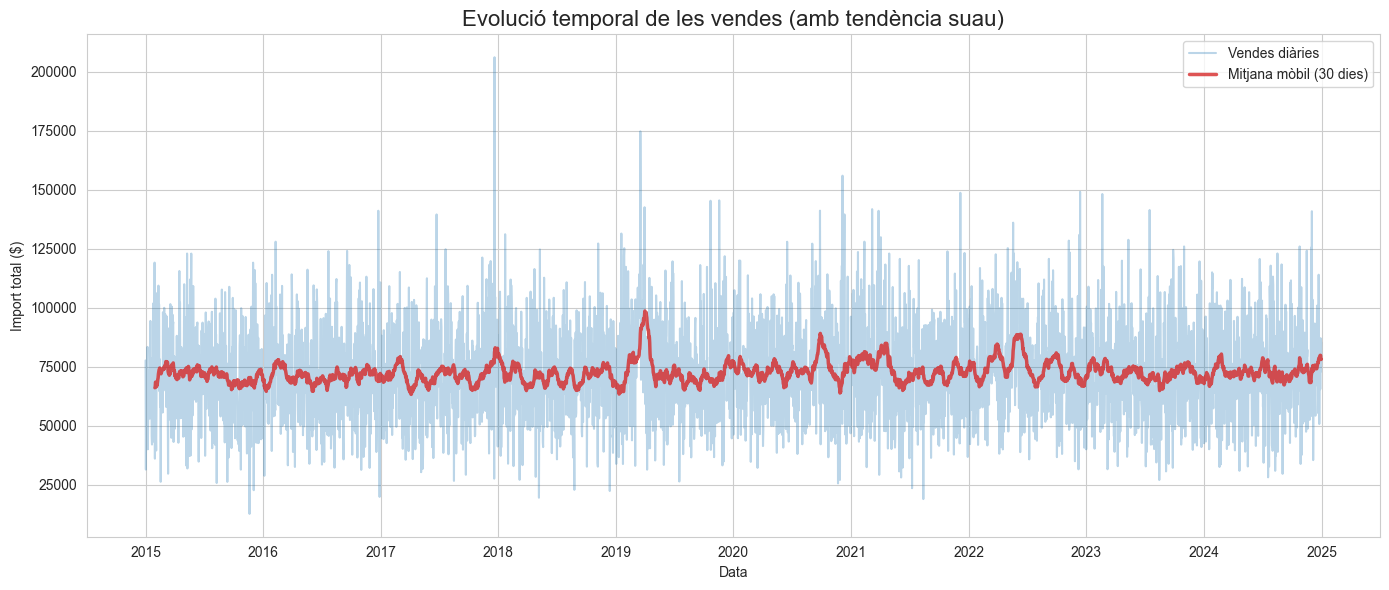

In [30]:
# --- Agregació temporal ---
df_daily = (
    super_df
    .set_index("timestamp")
    .resample("D")["amount"]
    .sum()
    .reset_index()
)

# --- Rolling mean ---
df_daily["rolling_30"] = df_daily["amount"].rolling(30).mean()   #Mitjana mòbil de 30 dies per veure millor la tendència a llarg termini. 

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

sns.lineplot(                           #Gràfic de línies per les vendes diàries
    data=df_daily,
    x="timestamp",
    y="amount",
    alpha=0.3,
    color="#1f77b4",
    label="Vendes diàries"
)

sns.lineplot(                   #Gràfic de línies per la mitjana mòbil
    data=df_daily,
    x="timestamp",
    y="rolling_30",
    color="#d62727ca",
    linewidth=2.5,
    label="Mitjana mòbil (30 dies)"
)

plt.title("Evolució temporal de les vendes (amb tendència suau)", fontsize=16)
plt.xlabel("Data")
plt.ylabel("Import total ($)")
plt.legend()
plt.tight_layout()
plt.show()


* <span style="font-size:20px">**Una variable categòrica.**

<span style="font-size:14px; color:deepskyblue">Com a variable categòrica treballarem amb la variable *declined*, que indica si una transacció va ser declinada (1) o no (0). Aquesta variable ens permet identifcar si hi ha una diferència en els imports de les transaccions que van ser declinades respecte a les que no ho van ser. Podem utilitzar aquesta variable per veure si hi ha algun patró o tendència en les transaccions declinades, i si aquestes tenen import més alts o més baixos que les transaccions no declinades.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\3109659937.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=super_df,                        #.coutplot --> gràfic de barres per a variables categòriques. Fa el recompte de cada categoria i ho mostra com a barres.


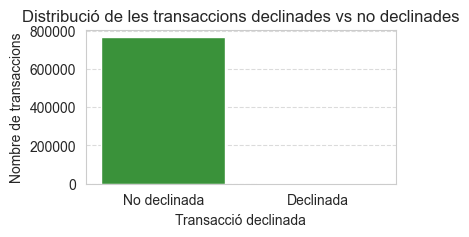

In [31]:
#Gràfic de barres per veure distribució de les transaccions declinades vs no declinades:
plt.figure(figsize=(4, 2))
sns.countplot(data=super_df,                        #.coutplot --> gràfic de barres per a variables categòriques. Fa el recompte de cada categoria i ho mostra com a barres. 
              x='declined',
              palette=['#2ca02c', "#bc3a0f"])    #Podem personalitzar els colors de les barres fent: palette=['color1', 'color2']. 
                                                     #El codi dels colors es pot trobar a https://htmlcolorcodes.com/es/ o a qualsevol altre lloc que ofereixi codis de colors en format hexadecimal.

plt.title("Distribució de les transaccions declinades vs no declinades")
plt.xlabel("Transacció declinada")
plt.ylabel("Nombre de transaccions")
plt.xticks(ticks=[0, 1], labels=['No declinada', 'Declinada'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:
# Transactions declinades vs aprovades
super_df["declined"].value_counts()

declined
False    766787
True       2368
Name: count, dtype: int64

<span style="color:red; font-size:16px">**Seria més interesant representar l'estat de les targetes: actiu vs inactiu.** 

In [33]:
card_status_df["status"].value_counts()
#La proporció és tan desequilibrada com en l'estudi/anàlisis de les transaccions aprovades vs declinades. 

status
active      4995
inactive       5
Name: count, dtype: int64

C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\1963571803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x="status", data=card_status_df, palette="crest", ax=ax)


Text(0, 0.5, 'Nombre de targetes')

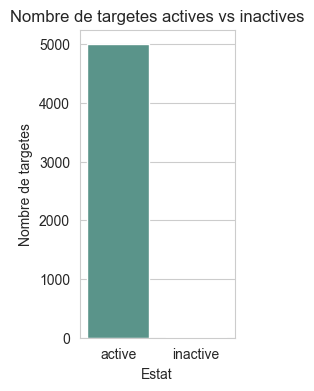

In [34]:
fig, ax=plt.subplots(figsize=(2, 4))
ax=sns.countplot(x="status", data=card_status_df, palette="crest", ax=ax)
ax.set_title("Nombre de targetes actives vs inactives")
ax.set_xlabel("Estat")
ax.set_ylabel("Nombre de targetes")

<span style="font-size:14px; color:maroon">**Observació**: Pràcticament no hi ha transaccions declinades ni targetes inactives. Potser seria millor treballar amb una altre variable categòrica com ara *product_ids* per veure les vendes que hi ha hagut de cada producte. O bé, amb *company_id* per veure les vendes que hi ha hagut per companyia.</span>

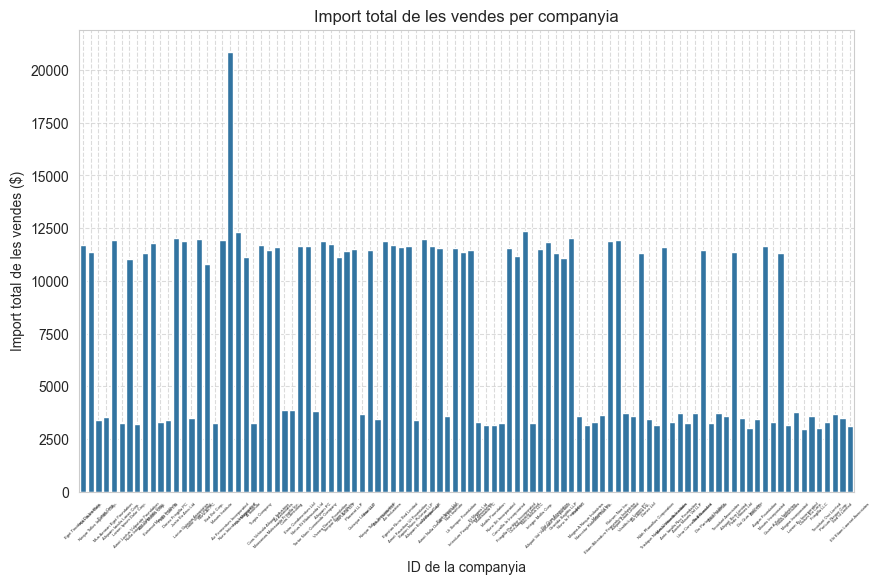

In [35]:
#Fem la representació gràfica de les vendes per companyia:
plt.figure(figsize=(10, 6))
sns.countplot(data=super_df,
              x='company_name')
plt.title("Import total de les vendes per companyia")
plt.xlabel("ID de la companyia")
plt.xticks(rotation=45, 
           fontsize=3)
plt.ylabel("Import total de les vendes ($)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [36]:
# Es molt caótica aquesta visualització. Podem observar que hi ha una companyia que sobresurt per damunt de les de més però no podem identificar quina companyia és. 

In [37]:
df_topcompany = (
    super_df.company_name.value_counts()
    .reset_index()
    .sort_values(by='count',ascending=False)
)
df_topcompany.head()

,company_name,count
0,Ac Fermentum Incorporated,20861
1,Orci Adipiscing Limited,12365
2,Nunc Interdum Incorporated,12335
3,Nunc In Foundation,12049
4,Donec Fringilla PC,12036


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\1129345230.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


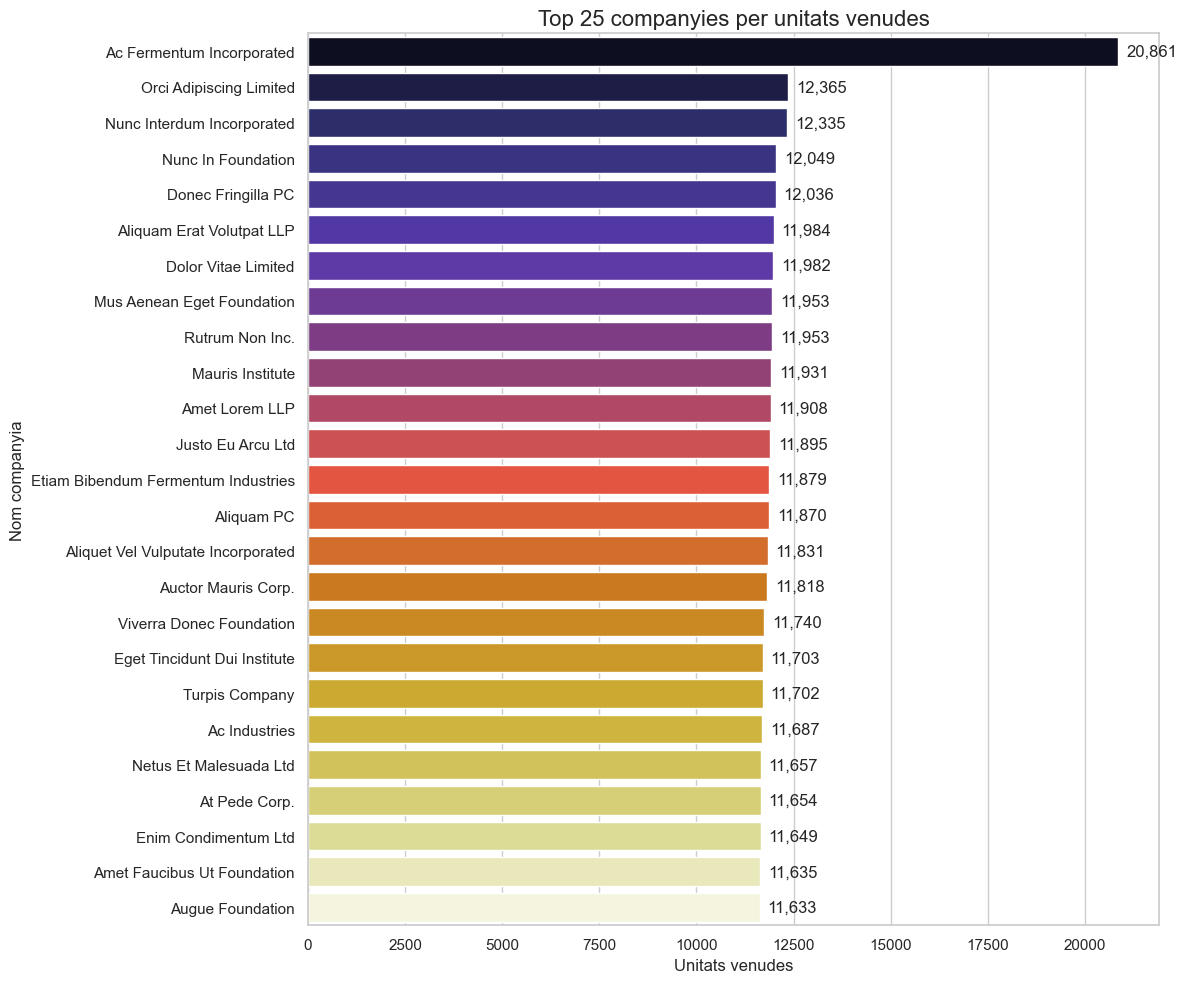

In [38]:
# Agregació
df_topcompany = (
    super_df.company_name.value_counts()
    .reset_index()
    .sort_values(by='count', ascending=False)
)

# Selecció top N
df_top = df_topcompany.head(25)

# Estètica
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=df_top,
    y="company_name",
    x="count",
    palette="CMRmap"
)

plt.title("Top 25 companyies per unitats venudes",
          fontsize=16)
plt.xlabel("Unitats venudes",
           fontsize=12)
plt.ylabel("Nom companyia",
           fontsize=12)

# Etiquetes numèriques
for i, v in enumerate(df_top["count"]):
    ax.text(v + 200, i, f"{v:,.0f}", va="center")

plt.tight_layout()
plt.show()


* <span style="font-size:20px">**Una variable categòrica i una numèrica.**

<span style="font-size:14px; color:deepskyblue">Com a variables categòrica i numèrica treballarem amb *country* i *amount*. La variable *country* ens permet veure les vendes per país, i la variable *amount* ens permet veure l'import de les vendes. Aquesta visualització ens ajudarà a identificar quins països tenen les vendes més altes i quins tenen les vendes més baixes, així com a veure si hi ha alguna diferència significativa en els imports de les vendes entre els diferents països.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\3251841494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


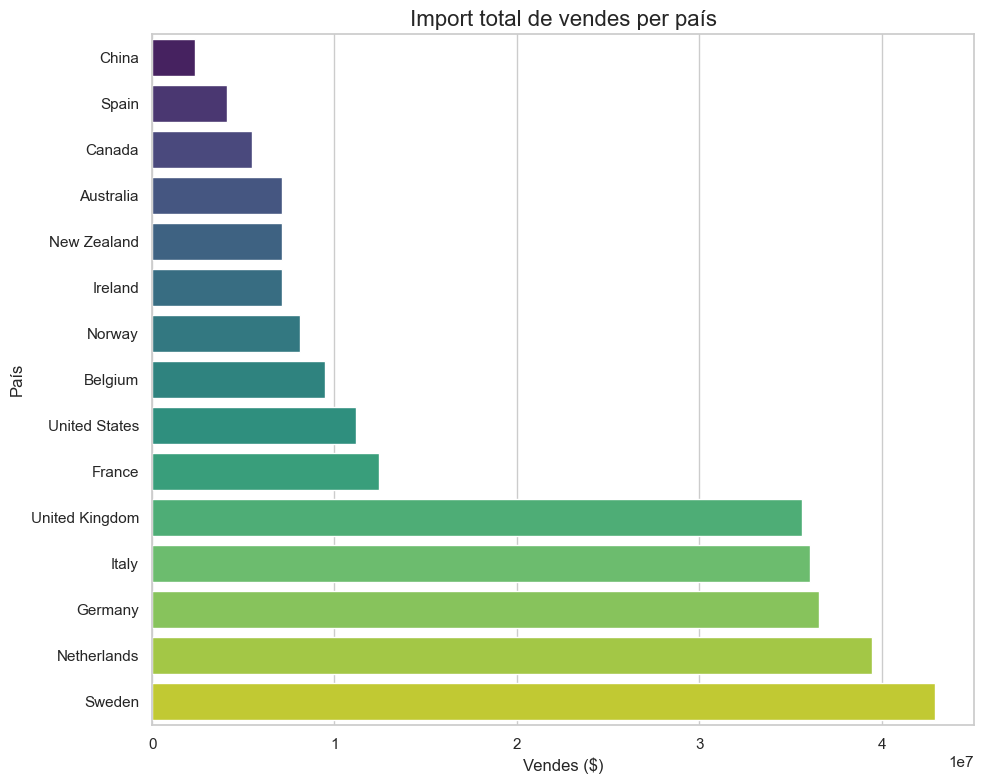

In [39]:
df_country = (
    super_df.groupby("country")["amount"]
    .sum()
    .reset_index()
    .sort_values("amount", ascending=True)
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=df_country,
    y="country",
    x="amount",
    palette="viridis"
)

plt.title("Import total de vendes per país",
          fontsize=16)
plt.xlabel("Vendes ($)")
plt.ylabel("País")
plt.tight_layout()
plt.show()


* <span style="font-size:20px">**Dues variables categòriques.**

In [40]:
#Transaccions declinades per país
declined_by_country = (
    super_df[super_df["declined"] == 1]
    .value_counts("country")
    .reset_index(name="count")
    .sort_values("count", ascending=True)
)

declined_by_country

,country,count
14,China,17
13,Spain,38
12,Canada,42
11,France,51
10,New Zealand,81
9,Ireland,96
8,Australia,98
7,Belgium,169
6,Germany,185
5,Norway,197


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\2602350065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


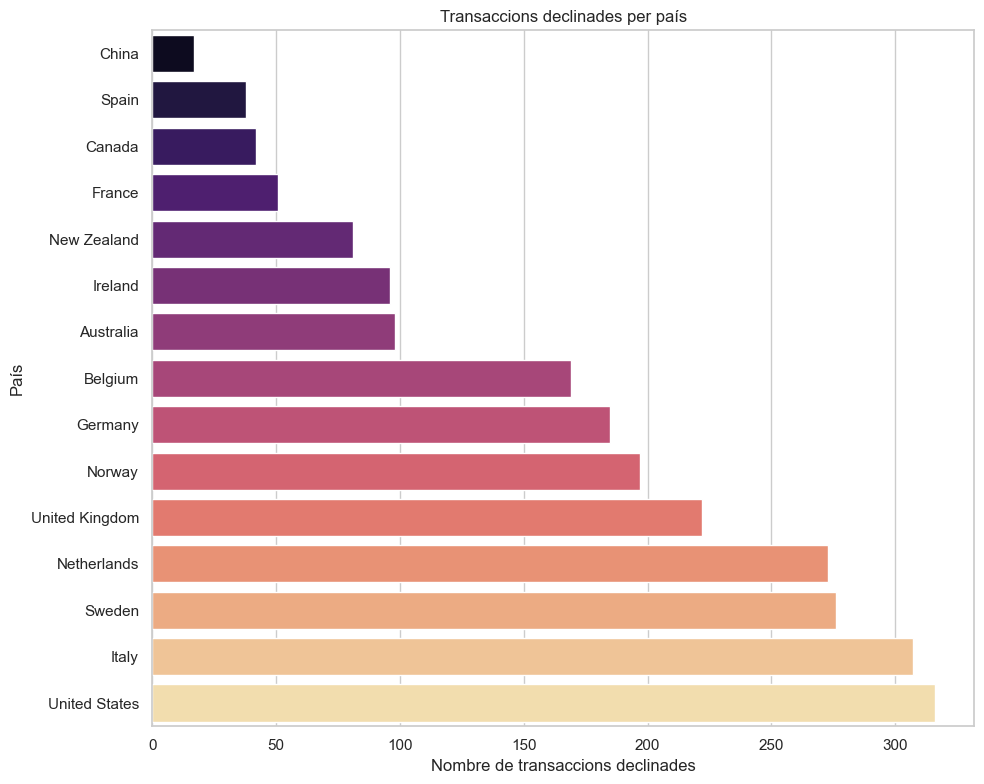

In [41]:
#Transaccions declinades per país:
plt.figure(figsize=(10,8))
sns.barplot(
    data=declined_by_country,
    y="country",
    x="count",
    palette="magma"
)

plt.title("Transaccions declinades per país")
plt.xlabel("Nombre de transaccions declinades")
plt.ylabel("País")
plt.tight_layout()
plt.show()

* <span style="font-size:20px">**Tres variables combinades.**

1. Preparar les dades

2. Calcular vendes per producte i país

3. Normalitzar (percentatges)

4. Reordenar països

5. Crear un stacked bar chart

In [42]:
#Preparar les dades:
vendes = (
    super_df
    .groupby(["country", "product_name"])["amount"]
    .sum()
    .reset_index()
)

vendes

,country,product_name,amount
0,Australia,Direwolf,176604.44
1,Australia,Direwolf Littlefinger,102099.16
2,Australia,Direwolf Stannis,197808.51
3,Australia,Direwolf Stannis riverlands,92428.46
4,Australia,Direwolf riverlands,81557.92
...,...,...,...
1045,United States,the duel warden,94582.80
1046,United States,the giantsblood maester,235772.83
1047,United States,warden,148494.11
1048,United States,warden Karstark,116655.71


In [43]:
#Vendes per país:
total_pais = (
    vendes.groupby("country")["amount"]
    .sum()
    .reset_index(name="total_country_sales")
)
total_pais.head()

,country,total_country_sales
0,Australia,7103195.94
1,Belgium,9487785.54
2,Canada,5479297.05
3,China,2342945.28
4,France,12464856.33


In [44]:
#Unir per normalitzar
vendes = vendes.merge(total_pais, on="country")
vendes.head()


,country,product_name,amount,total_country_sales
0,Australia,Direwolf,176604.44,7103195.94
1,Australia,Direwolf Littlefinger,102099.16,7103195.94
2,Australia,Direwolf Stannis,197808.51,7103195.94
3,Australia,Direwolf Stannis riverlands,92428.46,7103195.94
4,Australia,Direwolf riverlands,81557.92,7103195.94


In [45]:
#Normalitzar: percentatge de vendes per producte dins de cada país
vendes["percentatge"] = (vendes["amount"] / vendes["total_country_sales"] * 100).round(2)
vendes

,country,product_name,amount,total_country_sales,percentatge
0,Australia,Direwolf,176604.44,7103195.94,2.49
1,Australia,Direwolf Littlefinger,102099.16,7103195.94,1.44
2,Australia,Direwolf Stannis,197808.51,7103195.94,2.78
3,Australia,Direwolf Stannis riverlands,92428.46,7103195.94,1.30
4,Australia,Direwolf riverlands,81557.92,7103195.94,1.15
...,...,...,...,...,...
1045,United States,the duel warden,94582.80,11163557.39,0.85
1046,United States,the giantsblood maester,235772.83,11163557.39,2.11
1047,United States,warden,148494.11,11163557.39,1.33
1048,United States,warden Karstark,116655.71,11163557.39,1.04


In [46]:
#Reordenar per vendes:
vendes = vendes.sort_values("total_country_sales", ascending=False)
vendes.head(2)

,country,product_name,amount,total_country_sales,percentatge
840,Sweden,Direwolf,1069819.47,42923498.43,2.49
889,Sweden,riverlands north,518809.83,42923498.43,1.21


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\3991016969.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=vendes,


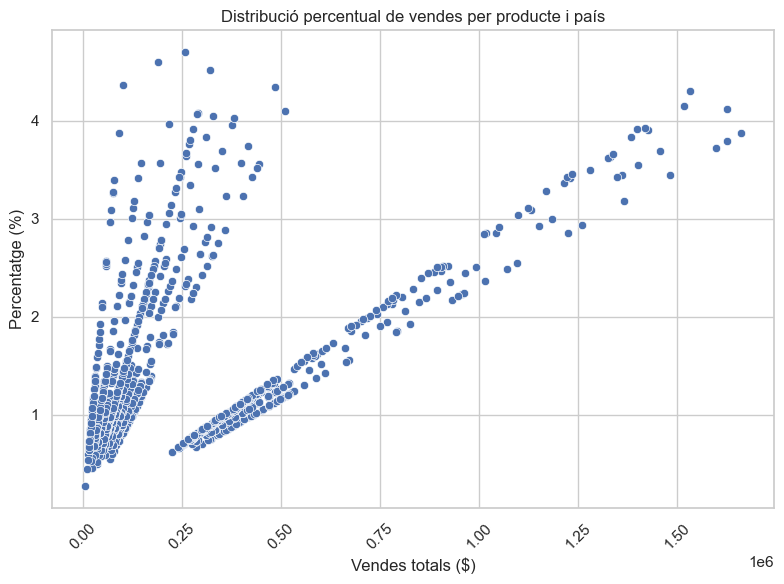

In [47]:
# Grafiquem:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=vendes,
                x="amount",
                y="percentatge",
                palette='Paired',
                legend="auto"
                )

plt.title("Distribució percentual de vendes per producte i país")
plt.xlabel("Vendes totals ($)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
#Reorganitzar dades en format ampli (wide) per stacked bar chart:
v_wide=vendes.pivot(
    index="country",
    columns="product_name",
    values="percentatge"
).fillna(0)

v_wide

product_name,Direwolf,Direwolf Littlefinger,Direwolf Stannis,Direwolf Stannis riverlands,Direwolf riverlands,Direwolf riverlands the,Dorne bastard,Jade tatooine dooku,Karstark Dorne,Karstark Tully Dorne,...,south,south duel,south duel tourney,tatooine dooku solo,the duel,the duel warden,the giantsblood maester,warden,warden Karstark,warden south duel
country,,,,,,,,,,,,,,,,,,,,,
Australia,2.49,1.44,2.78,1.30,1.15,1.14,0.96,1.07,2.70,1.07,...,0.77,0.87,0.86,0.87,4.07,1.27,2.11,1.17,0.87,1.00
Belgium,2.00,1.70,2.49,1.23,1.27,1.13,0.90,1.42,2.92,0.73,...,0.83,0.84,0.84,0.75,4.03,1.31,2.07,1.67,0.78,0.86
Canada,2.51,1.72,3.04,0.94,1.13,1.04,1.05,1.19,2.97,1.13,...,1.04,0.88,0.59,0.96,4.70,1.02,1.96,1.03,0.82,0.96
China,2.54,1.29,2.52,1.33,0.93,0.69,0.73,1.07,3.39,1.16,...,1.59,0.91,0.67,0.66,3.87,0.97,1.71,1.48,1.12,0.74
France,2.52,1.73,2.88,1.28,1.28,0.99,0.91,1.18,2.75,1.09,...,0.92,0.80,0.85,0.88,3.56,1.19,1.84,1.04,1.03,0.98
Germany,2.28,1.62,2.52,1.20,1.15,1.04,0.89,1.05,3.50,1.07,...,1.17,1.05,0.83,0.76,3.62,1.60,1.68,1.32,0.88,0.92
Ireland,2.13,1.55,2.57,1.54,1.06,1.15,0.91,1.22,2.78,0.82,...,1.00,0.81,1.06,0.90,4.08,1.29,1.67,1.21,1.10,0.97
Italy,2.45,1.55,3.04,1.21,1.11,1.01,0.95,1.17,2.91,0.99,...,0.85,0.88,0.91,0.92,3.83,1.17,1.95,1.29,0.79,0.93
Netherlands,2.27,1.68,2.92,1.12,1.13,1.19,1.08,1.28,3.00,0.92,...,0.90,0.84,0.89,0.84,4.12,1.31,1.94,1.32,0.94,1.02


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\4086950515.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

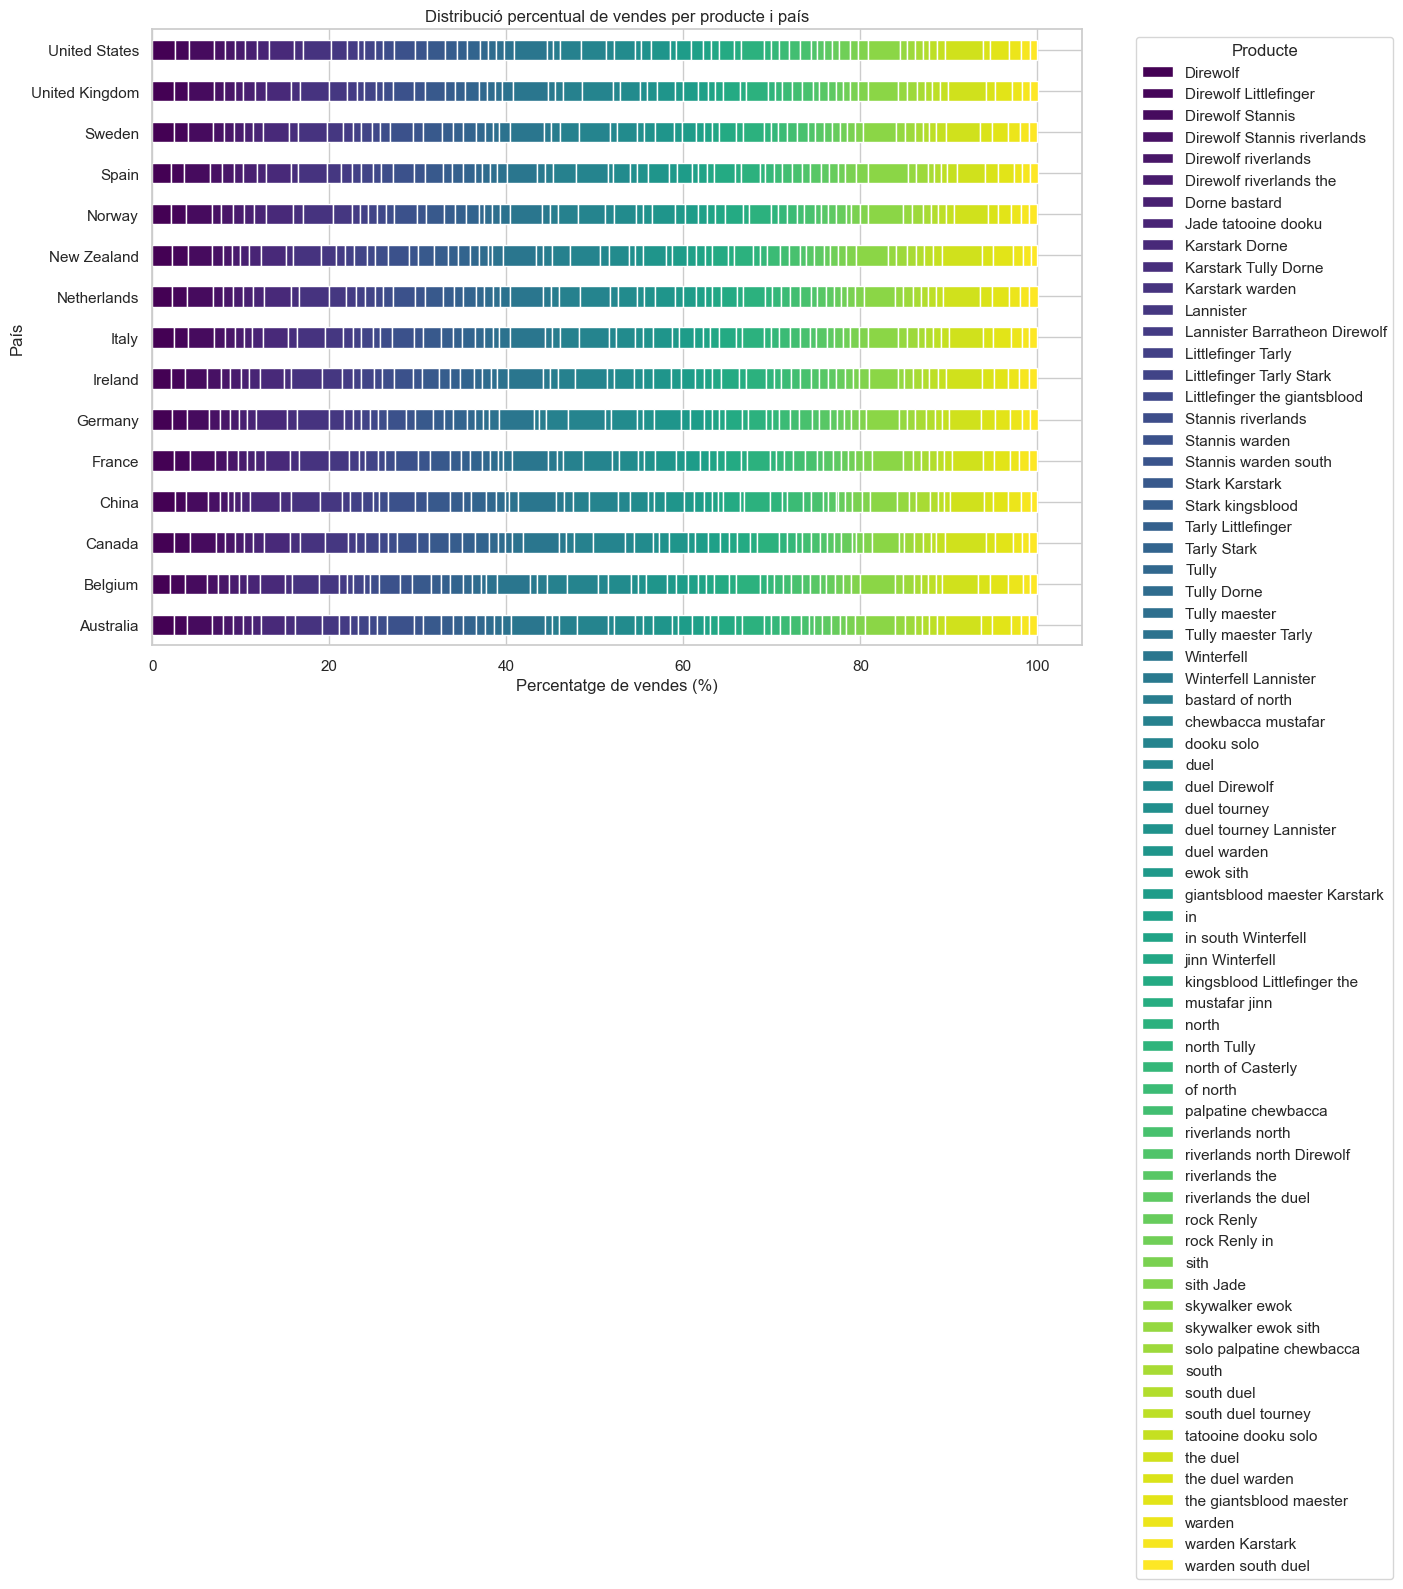

In [49]:
# Grafiquem:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

v_wide.plot(
    kind="barh",
    stacked=True,
    colormap="viridis",
    figsize=(12, 8)
)

plt.title("Distribució percentual de vendes per producte i país")
plt.xlabel("Percentatge de vendes (%)")
plt.ylabel("País")
plt.legend(title="Producte", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\430056039.py:50: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


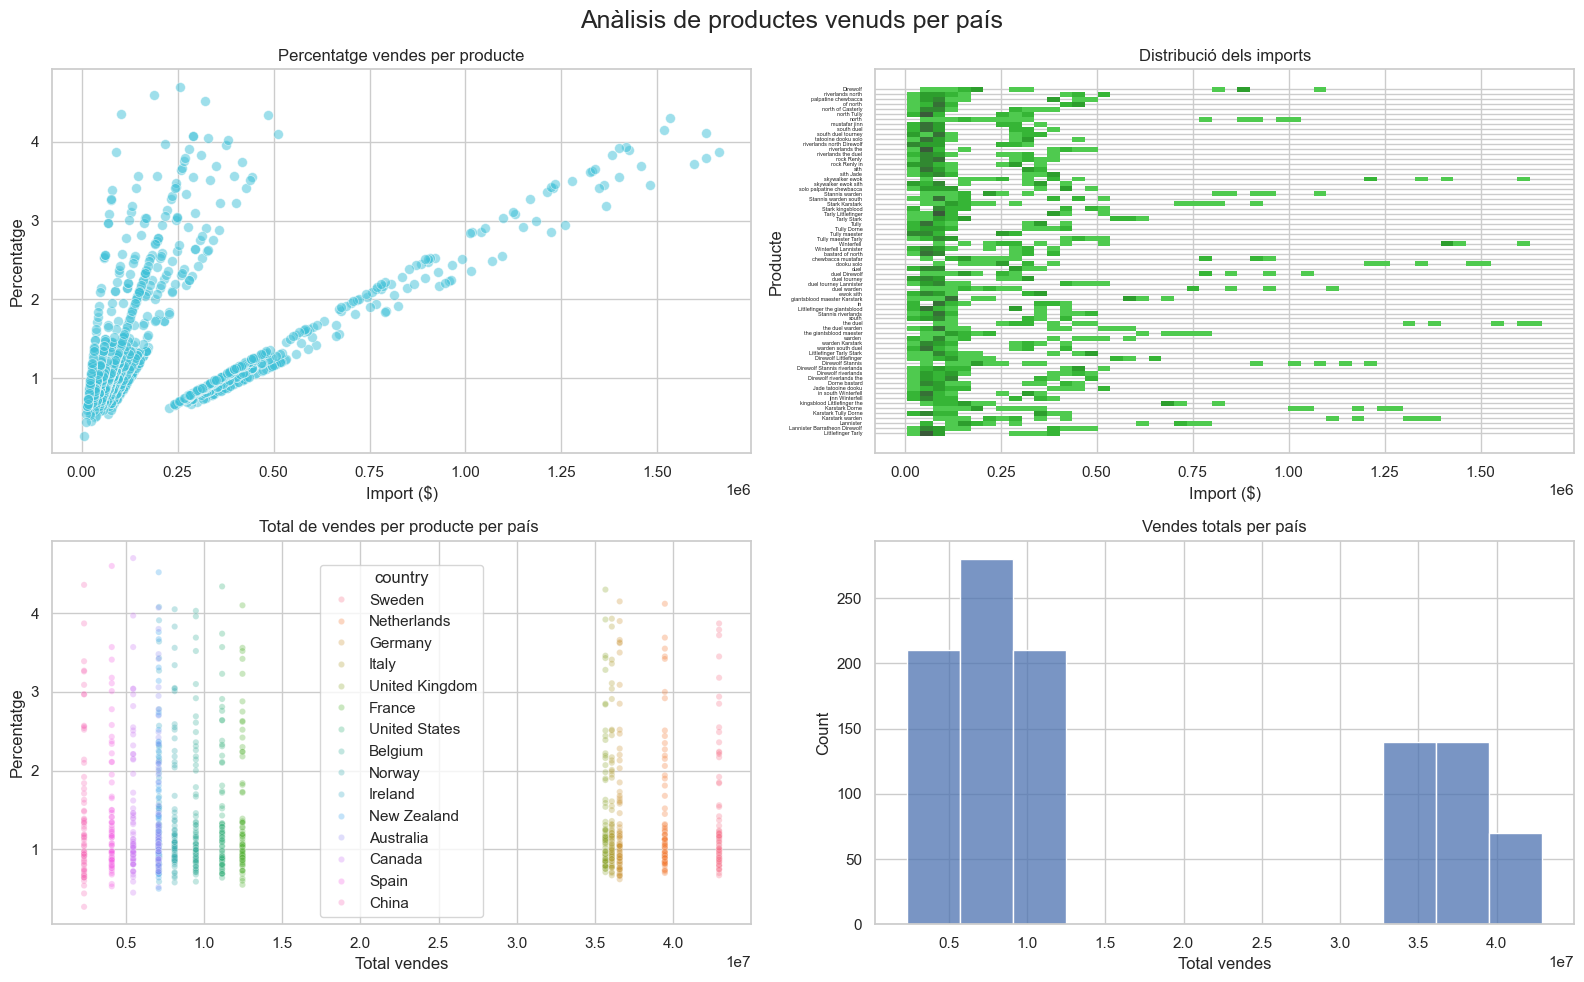

In [50]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Anàlisis de productes venuds per país", fontsize=18)

# --- 1. Scatterplot temporal ---
sns.scatterplot(
    data=vendes,
    x="amount",
    y="percentatge",
    alpha=0.5,
    s=50,
    color="#3ec1d8",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Percentatge vendes per producte")
axes[0, 0].set_xlabel("Import ($)")
axes[0, 0].set_ylabel("Percentatge")

# --- 2. Histograma d'import ---
sns.histplot(
    data=vendes,
    x="amount",
    y="product_name",
    bins=50,
    kde=True,
    color="#2ca02c",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribució dels imports")
axes[0, 1].set_xlabel("Import ($)")
axes[0, 1].set_ylabel("Producte")
axes[0, 1].tick_params(axis='y', labelsize=4)

# --- 3. Scatter agregat per país ---
sns.scatterplot(
    data=vendes,
    x="total_country_sales",
    y="percentatge",
    hue="country",
    alpha=0.3,
    s=20,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Total de vendes per producte per país ")
axes[1, 0].set_xlabel("Total vendes")
axes[1, 0].set_ylabel("Percentatge")

# --- 3. Scatter agregat per país ---
sns.histplot(
    data=vendes,
    x="total_country_sales",
    palette='PuBu',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Vendes totals per país")
axes[1, 1].set_xlabel("Total vendes")

plt.tight_layout()
plt.show()


* <span style="font-size:20px">**Crea un Pairplot.**

<span style="font-size:12px"> Per crear el *Pairplot* utilitzarem el dataframe que hem creat en l'apartat anterior, afegint l'any. És a dir, volem estudiar si hi ha una tendència en els productes més venuts que es mante al llarg del temps. 

In [51]:
vendes.info()
vendes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 840 to 216
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              1050 non-null   object 
 1   product_name         1050 non-null   object 
 2   amount               1050 non-null   float64
 3   total_country_sales  1050 non-null   float64
 4   percentatge          1050 non-null   float64
dtypes: float64(3), object(2)
memory usage: 49.2+ KB


,country,product_name,amount,total_country_sales,percentatge
840,Sweden,Direwolf,1069819.47,42923498.43,2.49
889,Sweden,riverlands north,518809.83,42923498.43,1.21
888,Sweden,palpatine chewbacca,495539.42,42923498.43,1.15
887,Sweden,of north,451898.49,42923498.43,1.05
886,Sweden,north of Casterly,339041.23,42923498.43,0.79


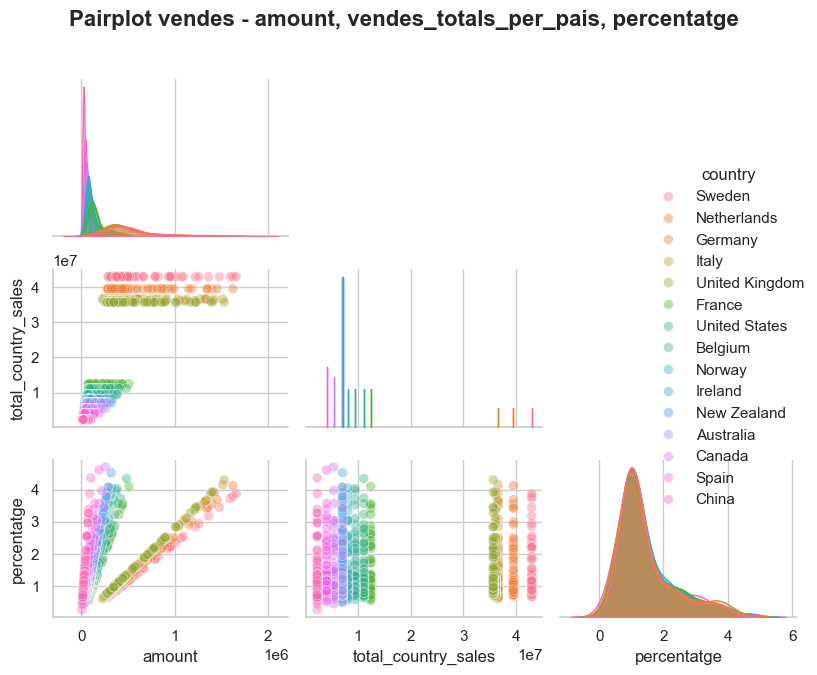

In [52]:

# Variables numéricas clave (de tu imagen)
vars_pair = ['amount', 'total_country_sales', 'percentatge']

# Pairplot
sns.set_palette("husl")
sns.set_style("whitegrid")

sns.pairplot(
    vendes[vars_pair + ['country']],
    vars=vars_pair,
    hue='country',
    diag_kind='kde',      # Distribuciones elegantes
    kind='scatter',
    corner=True,          # Triángulo inferior
    height=2.2,
    plot_kws={'alpha': 0.4, 's': 50}
)

plt.suptitle('Pairplot vendes - amount, vendes_totals_per_pais, percentatge', 
               fontsize=16,
               fontweight='bold',
               y=1.02)
plt.tight_layout()
plt.show()

<span style="font-size:40px; color:turquoise"> **Nivell 2**

1. <span style="font-size:14px">**Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.**

In [53]:
#Podem estudiar la correlació que hi ha entre les vendes i el preu del producte: 
# super_df["amount"].corr(super_df["price"]) --> Retorna error perquè 'price' és de tipus objecte.

#1) Convertim 'price' a numèric:
#super_df["price"]=super_df["price"].str.replace('$', '', regex=False).astype(float)    --> JA HO HEM FET AL INICI durant la transformació

<span style="font-size:14px; color:slateblue">**Volem estudiar la correlació que hi ha entre el preu del producte i les vendes per país. Per fer-ho hem de seguir els següents passos:**

1. <span style="font-size:14px; color:slateblue">**Primer necessitem un dataframe agregat per producte i país:**
* <span style="font-size:12px; color:slateblue">Preu mitjà del producte
* <span style="font-size:12px; color:slateblue">Quantitat total venuda
* <span style="font-size:12px; color:slateblue">Nombre de transaccions
* <span style="font-size:12px; color:slateblue">Import total venut



In [54]:
avg_pric=super_df.groupby(['country', 'product_name'])['price'].mean().round(2)
avg_pric

country        product_name               
Australia      Direwolf                       169.57
               Direwolf Littlefinger           33.00
               Direwolf Stannis               102.02
               Direwolf Stannis riverlands    170.76
               Direwolf riverlands            167.07
                                               ...  
United States  the duel warden                180.91
               the giantsblood maester         82.27
               warden                         196.65
               warden Karstark                 91.96
               warden south duel               71.89
Name: price, Length: 1050, dtype: float64

In [55]:
super_df[["product_name","price"]]

,product_name,price
id,,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,the duel warden,180.91
00043A49-2949-494B-A5DD-A5BAE3BB19DD,Stark Karstark,53.01
00043A49-2949-494B-A5DD-A5BAE3BB19DD,jinn Winterfell,65.25
00043A49-2949-494B-A5DD-A5BAE3BB19DD,sith Jade,96.26
00043A49-2949-494B-A5DD-A5BAE3BB19DD,the duel warden,180.91
...,...,...
FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,Karstark warden,148.91
FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,rock Renly in,21.53
FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,Stark Karstark,53.01


In [56]:
#Com que ens dona ERROR si comptem directament l"id" perquè l'hem posat com a index i ja no es tracta d'una columna. 
#Hem de fer la següent modificació:
df2=super_df.reset_index()

# Agrupació per país i producte
agg= (
    df2.groupby(["country", "product_name"])
    .agg(
        total_sales=("amount", "sum"),
        n_transactions=("id", "count"),
        price=("price", 'mean')     # price preu per producte.
    )
    .reset_index()
)

agg["price"]=agg["price"].round(2)
agg


,country,product_name,total_sales,n_transactions,price
0,Australia,Direwolf,176604.44,419,169.57
1,Australia,Direwolf Littlefinger,102099.16,355,33.00
2,Australia,Direwolf Stannis,197808.51,583,102.02
3,Australia,Direwolf Stannis riverlands,92428.46,212,170.76
4,Australia,Direwolf riverlands,81557.92,193,167.07
...,...,...,...,...,...
1045,United States,the duel warden,94582.80,226,180.91
1046,United States,the giantsblood maester,235772.83,703,82.27
1047,United States,warden,148494.11,330,196.65
1048,United States,warden Karstark,116655.71,346,91.96


2. <span style="font-size:14px; color:slateblue">**Correlació preu-vendes per país:** <br>
<span style="font-size:12px; color:slateblue">Ara calculem la correlació dins de cada país <br>
<span style="font-size:13px; color:red">**Interpretació:**

* <span style="font-size:12px">Valor negatiu → els productes barats es venen més
* <span style="font-size:12px">Valor positiu → els productes cars es venen més
* <span style="font-size:12px">Valor proper a 0 → no hi ha correlació clara </span>

In [57]:
correlations = (
    agg.groupby("country")
    .apply(lambda g: g["price"].corr(g["total_sales"]))
    .reset_index(name="corr_price_sales")
)

correlations


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\1661881775.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["price"].corr(g["total_sales"]))


,country,corr_price_sales
0,Australia,0.275852
1,Belgium,0.270514
2,Canada,0.221234
3,China,0.263742
4,France,0.285540
5,Germany,0.254042
6,Ireland,0.248712
7,Italy,0.261721
8,Netherlands,0.254669
9,New Zealand,0.245183


3. <span style="font-size:14px; color:slateblue">**Visualitzar la correlació entre el preu mitjà i les vendes totals per país:**

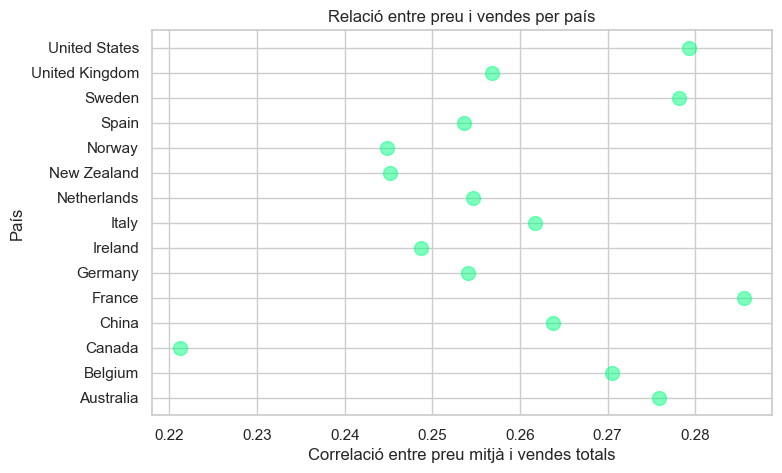

In [58]:
plt.figure(figsize=(8, 5))
plt.scatter(correlations["corr_price_sales"],
            correlations["country"],
            color='springgreen',
            s=100, #Mida dels punts
            alpha=0.5) #Transparència dels punts
plt.xlabel("Correlació entre preu mitjà i vendes totals")
plt.ylabel("País")
plt.title("Relació entre preu i vendes per país")
plt.show()


<span style="font-size:14px; color:deepskyblue"> **Observació**: Tots són valors propers a zero, per tant, no podem assegurar que hi hagi una correlació entre el volum de vendes i el preu del producte en els diferents països.

<span style="font-size:16px; color: red">**Per estudiar la relació que hi ha entre aquestes variables, calcularem amb la p-value per país.**

In [59]:
#Per fer l'estadística de correlació més formal, podem utilitzar el test de Pearson, que ens donarà el coeficient de correlació i la p-value per cada país.
#1) Importem la funció de Pearson de la llibreria scipy.stats: 
from scipy.stats import pearsonr

results = [] # Creem una llista per emmagatzemar els resultats de la corr per cada país

for country, group in agg.groupby("country"):
    # Evitem errors si hi ha valors constants
    if group["price"].nunique() > 1 and group["total_sales"].nunique() > 1:
        corr, pval = pearsonr(group["price"], group["total_sales"])             # El que estem fent aquí és calcular la corrlecaió de Pearson entre el preu mitjà i les vendes totals per cada país. 
        results.append({"country": country, "corr": corr, "pval": pval})
    else:
        results.append({"country": country, "corr": None, "pval": None})

corr_df = pd.DataFrame(results)
corr_df


,country,corr,pval
0,Australia,0.275852,0.020809
1,Belgium,0.270514,0.023517
2,Canada,0.221234,0.065691
3,China,0.263742,0.027376
4,France,0.285540,0.016571
5,Germany,0.254042,0.033826
6,Ireland,0.248712,0.037880
7,Italy,0.261721,0.028627
8,Netherlands,0.254669,0.033373
9,New Zealand,0.245183,0.040780


In [60]:
# Filtrem aquells països on la corr és significativa (p-value < 0.05) i ordenem per força de correlació:
corr_significant= corr_df[corr_df["pval"]<0.05].sort_values(by="corr", ascending=True)
corr_significant

,country,corr,pval
10,Norway,0.244823,0.041087
9,New Zealand,0.245183,0.040780
6,Ireland,0.248712,0.037880
11,Spain,0.253630,0.034125
5,Germany,0.254042,0.033826
8,Netherlands,0.254669,0.033373
13,United Kingdom,0.256833,0.031852
7,Italy,0.261721,0.028627
3,China,0.263742,0.027376
1,Belgium,0.270514,0.023517


C:\Users\dioul\AppData\Local\Temp\ipykernel_55904\97258025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="corr",


Text(0, 0.5, 'País')

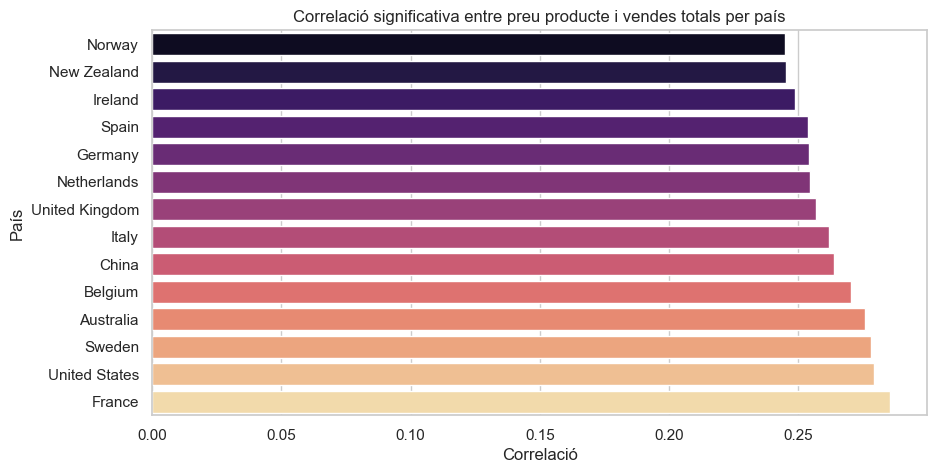

In [61]:
#Visualitzem només els països amb corr significativa: 
plt.figure(figsize=(10,5))
sns.barplot(x="corr",
            y="country",
            data=corr_significant,
            palette="magma")
plt.title("Correlació significativa entre preu producte i vendes totals per país")
plt.xlabel("Correlació",
           fontsize=12)
plt.ylabel("País",
           fontsize=12)

<span style="font-size:20px; color:red">**Fer matriu de correlació:**

Text(0.5, 1.0, 'Matriu de correlació entre preu producte i vendes totals')

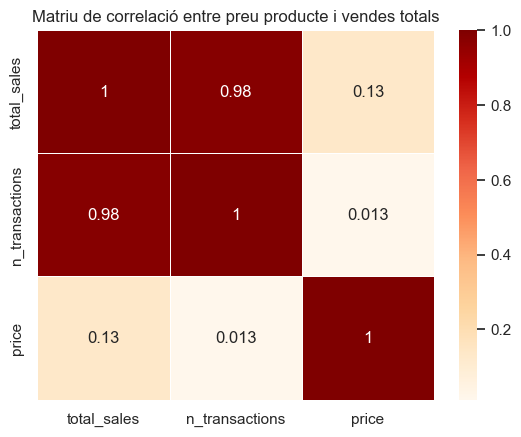

In [62]:
#Matriu de correlació
sns.heatmap(agg[["total_sales", "n_transactions", "price"]].corr(),
            annot=True,
            cmap="OrRd",
            linewidths=0.5,         #Afegim línies entre les cel·les per millorar la llegibilitat
            linecolor='white')
plt.title("Matriu de correlació entre preu producte i vendes totals")


2. <span style="font-size:14px">**Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.**

In [63]:
super_df.head()

,card_id,company_id,timestamp,amount,declined,product_ids,user_id,product_name,price,company_name,country,website
id,,,,,,,,,,,,
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,16,4713,the duel warden,180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,26,4713,Stark Karstark,53.01,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,97,4713,jinn Winterfell,65.25,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,87,4713,sith Jade,96.26,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r
00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,False,16,4713,the duel warden,180.91,Eget Tincidunt Dui Institute,Netherlands,https://wikipedia.org/user/110\r


In [64]:
users_df.birth_date.dtype

dtype('O')

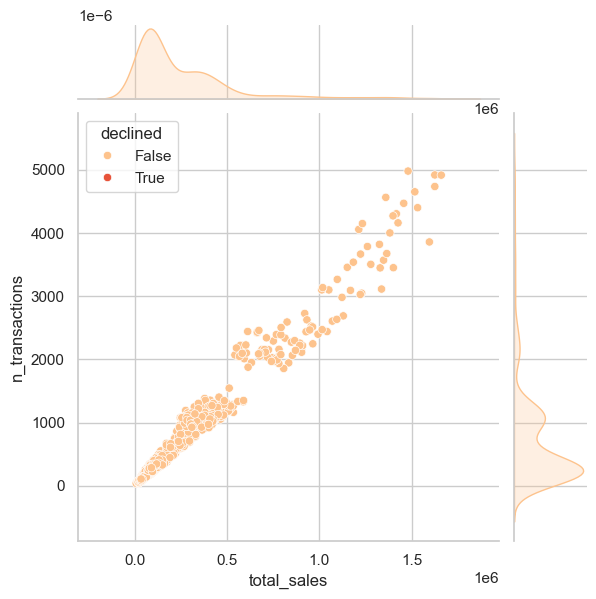

In [65]:
sns.jointplot(data=agg,
              x='total_sales',
              y='n_transactions',
              hue=df2.declined,
              kind='scatter',
              palette="OrRd")

<span style="font-size:40px; color: turquoise">**Nivell 3**

1. <span style="font-size:14px">**Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.**

<span style="font-size:16px; color:orange">**Recorda**: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació

<span style="font-size:14px"> Com connectem *PowerBI* amb python?

<span style="font-size:16px; color:deepskyblue">**Per connectar Power BI amb Python, segueix aquests passos:**</span>
1. <span style="font-size:14px; color:deepskyblue">Instal·la Python i les biblioteques necessàries (com pandas, matplotlib, seaborn, etc.) si encara no les tens instal·lades.</span>
2. <span style="font-size:14px; color:deepskyblue">Obre Power BI Desktop i ves a "File" > "Options and settings" > "Options".</span>
3. <span style="font-size:14px; color:deepskyblue">A la secció "Python scripting", selecciona la ruta on tens instal·lat Python i les biblioteques necessàries.</span>
4. <span style="font-size:14px; color:deepskyblue">Ara pots utilitzar scripts de Python per crear visualitzacions personalitzades a Power BI. Simplement selecciona "Python visual" a la barra d'eines de visualització, escriu el teu codi Python i Power BI executarà el script per generar la visualització.</span>
5. <span style="font-size:14px; color:red">**Recorda que quan utilitzis scripts de Python a Power BI, el teu codi ha de generar un DataFrame com a resultat, ja que Power BI utilitzarà aquest DataFrame per crear la visualització. Assegura't de retornar el DataFrame amb les dades que vols visualitzar**.</span>

<span style="font-size:14px; color: orange">**Observacions**

* <span style="font-size:14px">Recorda que quan utilitzis scripts de Python a Power BI, és important assegurar-te que el teu codi sigui eficient i optimitzat, ja que Power BI executarà el script cada vegada que actualitzis les dades o interactuïs amb la visualització. Assegura't de gestionar adequadament les dependències i les biblioteques que utilitzes en el teu script per evitar errors i garantir un rendiment òptim.</span>
* <span style="font-size:14px">A més, és important tenir en compte que les visualitzacions creades amb Python a Power BI poden no ser tan interactives com les visualitzacions nadiues de Power BI, ja que depenen del codi Python per generar-se. Per tant, és recomanable utilitzar scripts de Python per crear visualitzacions estàtiques o semi-interactives, i combinar-les amb altres visualitzacions nadiues de Power BI per crear informes més complets i interactius.</span>  
* <span style="font-size:14px">En resum, connectar Power BI amb Python et permet utilitzar la potència de Python per crear visualitzacions personalitzades i realitzar anàlisis avançats, tot integrat dins de l'entorn de Power BI per crear informes interactius i informatius. Assegura't de seguir les bones pràctiques en la creació dels teus scripts de Python per garantir un rendiment òptim i una experiència d'usuari satisfactòria a Power BI.</span>  

Què has de fer si el que vols és carregar les visualitzacions que has creat a Power BI?

Has de seguir els següents passos:
1. <span style="font-size:14px; color:deepskyblue">Obre Power BI Desktop i ves a "Home" > "Get Data" > "Python script".</span>
2. <span style="font-size:14px; color:deepskyblue">A visualitzacions selecciona "Py". A valors afegeix les variables/parametres/columnes amb les que volguis treballar. Aquestes conformaran el teu dataset.</span>
3. <span style="font-size:14px; color:deepskyblue">A la finestra que se t'obra sota la fulla/'lienzo' on generar les teves visualitzacions, enganxa-hi el teu codi.<span style="font-size:14; color:red"> **Recorda**:</span><span style="font-size:14px; color:deepskyblue"> Que les teves dades són les columnes que has afegeit a *valors* (**el teu dataset**), per tant, a l'hora de crear el teu script has de substituir el nom del teu *dataframe* per *dataset*. 
4. <span style="font-size:14px; color:deepskyblue">Power BI executarà el teu script de Python i generarà la visualització basada en les dades que has retornat en el DataFrame o dataset. Ara pots utilitzar aquesta visualització dins dels teus informes de Power BI i combinar-la amb altres visualitzacions de Power BI per crear informes més complets i interactius.</span> 

<span style="font-size:20px; font-weight:bold">[Embed a Power BI component in a Jupyter notebook](https://learn.microsoft.com/en-us/javascript/api/overview/powerbi/powerbi-jupyter)

In [66]:
from powerbiclient import Report, models


ModuleNotFoundError: No module named 'powerbiclient'

In [ ]:
#!py -m pip uninstall powerbiclient

In [ ]:
# Import the DeviceCodeLoginAuthentication class to authenticate against Power BI:
from powerbiclient.authentication import DeviceCodeLoginAuthentication

# Initiate device authentication
device_auth = DeviceCodeLoginAuthentication()

Performing device flow authentication. Please follow the instructions below.
To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code G7GH49CNM to authenticate.


KeyboardInterrupt: 

<span style="font-size:18px; color:red">**Necessitem un compte professional per poder integrar Power BI amb Jupyter Notebook.**</span>  